# 1. Imports and Data Loading

In [1]:
import math
import os
import numpy as np # linear algebra
import seaborn as sns
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.parallel import Parallel, delayed
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer

This notebook is designed to work on kaggle and locally, therefore the files must be retrieved.

In [2]:
def load_data():
    '''try to load the data from the local directory, if not found, load it from the Kaggle dataset. Output the three dataframes: train, test, and submission.'''
    
    try:
        # check if the data files are in kaggle /kaggle/input/competitions/playground-series-s6e6 directory
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
        test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
        submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
        print("Data loaded successfully from kaggle input directory.")
    except FileNotFoundError:
        print("Data files not found in kaggle input directory. \nTrying to load data from local directory...")
        # Load data from local directory 
        data_dir = os.getcwd()+ '/data/'
        train = pd.read_csv(data_dir + 'train.csv')
        test = pd.read_csv(data_dir + 'test.csv')
        submission = pd.read_csv(data_dir + 'sample_submission.csv') 
        print("Data loaded successfully from local directory.")

    return train, test, submission


train_df, test_df, submission_df = load_data()

Trying to load data from kaggle input directory...
Data files not found in kaggle input directory. 
Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data Exploration

In [3]:
train_df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [4]:
train_df.notnull().sum()    

id                   577347
alpha                577347
delta                577347
u                    577347
g                    577347
r                    577347
i                    577347
z                    577347
redshift             577347
spectral_type        577347
galaxy_population    577347
class                577347
dtype: int64

In [5]:
def quality_check(df):
    '''check for missing values, duplicated rows, and data types of each column in the dataframe.
    Parameters:
    df (pandas dataframe): the dataframe to check for quality issues.
    '''
    temp_df = df.copy()

    print(f"The total number of missing values in the training dataset is: {temp_df.isnull().sum().sum()}")
    #print dashes equal to the length of the above print statement
    print("-" * len(f"The total number of missing values in the training dataset is: {temp_df.isnull().sum().sum()}"))
    print(f"The total number of duplicated rows in the training dataset is: {temp_df.duplicated().sum()}")
    #print dashes equal to the length of the above print statement
    print("-" * len(f"The total number of duplicated rows in the training dataset is: {temp_df.duplicated().sum()}"))
    print(f"The data types of each column in the training dataset are:\n{temp_df.dtypes}")
    

quality_check(train_df)

The total number of missing values in the training dataset is: 0
----------------------------------------------------------------
The total number of duplicated rows in the training dataset is: 0
-----------------------------------------------------------------
The data types of each column in the training dataset are:
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object


The class distribution in the target column 'class' is:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


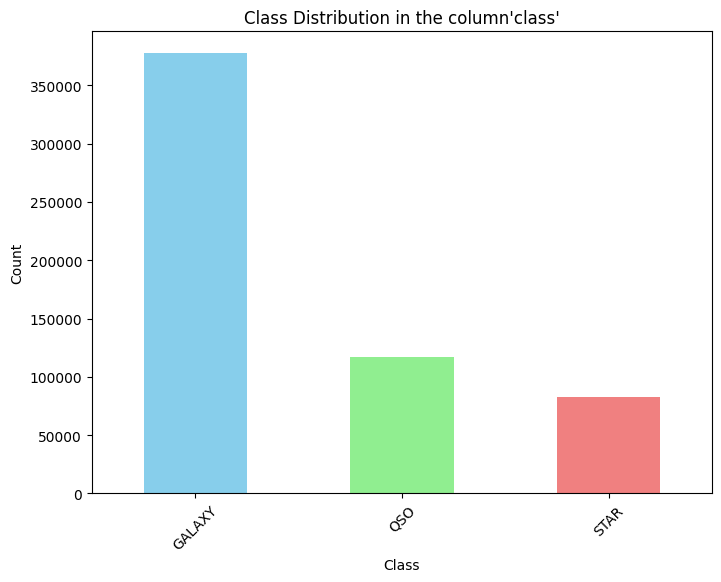

In [6]:
def class_imbalance_check(df, target_col):
    '''Check for class imbalance in the target column of the dataframe.Accepts the dataframe and the name of the targer column as arguments.'''
    class_counts = df[target_col].value_counts()
    print(f"The class distribution in the target column '{target_col}' is:\n{class_counts}")
    #plot the class distribution as a bar chart using matplotlib
    #give the bars different colors
    #
    plt.figure(figsize=(8, 6))
    class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    plt.title(f"Class Distribution in the column'{target_col}'")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

target_column = 'class'
class_imbalance_check(train_df, target_column)

# 3.Data Preprocessing

## 3.1 Categorical feature preprocesssing

The data is prepared for training by dropping unnecessary columns like `id` which will not influence the target class. Furthermore, the target column `class` is mapped to integers for convinience working with models. 
Since `spectral_type` on has 2 unique variables, binary encoding is suitable. In contrast `galaxy_population` has multiple variables and therefore one hot encoding is required to avoid models misinterpreting  the interger representation of the column for varrying magnitudes.  

In [7]:
def drop_id_column(df):
    '''Drop the 'id' column from the dataframe if it exists.'''
    temp_df = df.copy()
    if 'id' in temp_df.columns:
        temp_df = temp_df.drop(columns=['id'])
        print("The 'id' column has been dropped from the dataframe.")
    else:
        print("The 'id' column does not exist in the dataframe.")
    return temp_df

no_id_train_df = drop_id_column(train_df)
no_id_train_df.head()


The 'id' column has been dropped from the dataframe.


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [8]:
def preprocess_categorical_features(df, target_col):
    '''Preprocess the categorical features in the dataframe. 
    This function will re-map the target variable to numerical values using a dictionary mapping GALAXY to 0, QSO to 1 and STAR to 2. 
    It will also  binary encode the galaxy_population column, and apply one-hot encoding to the spectral_type column.'''

    temp_df = df.copy()
    #Re-map the target variable to numerical values using a dictionary mapping GALAXY to 0, QSO to 1 and STAR to 2.
    class_mapping = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
    temp_df[target_col] = temp_df[target_col].map(class_mapping)

    # Take the unique values in galaxy_population column
    galaxy_population_unique = temp_df['galaxy_population'].unique()
    # Binary encode galaxy_population
    galaxy_population_mapping = {value: idx for idx, value in enumerate(galaxy_population_unique)}
    # Apply the mapping to the galaxy_population column
    temp_df['galaxy_population'] = temp_df['galaxy_population'].map(galaxy_population_mapping)

    #Applying one-hot encoding to spectral_type column
    temp_df = pd.get_dummies(temp_df, columns=['spectral_type'], drop_first=True, dtype=int)
    return temp_df

target_col = 'class'
preprocessed_categorical_train_df = preprocess_categorical_features(no_id_train_df, target_col)
preprocessed_categorical_train_df.head()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,1,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,1,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,0,0,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,1,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,1,0


## 3.2 Numerical feature preprocessing

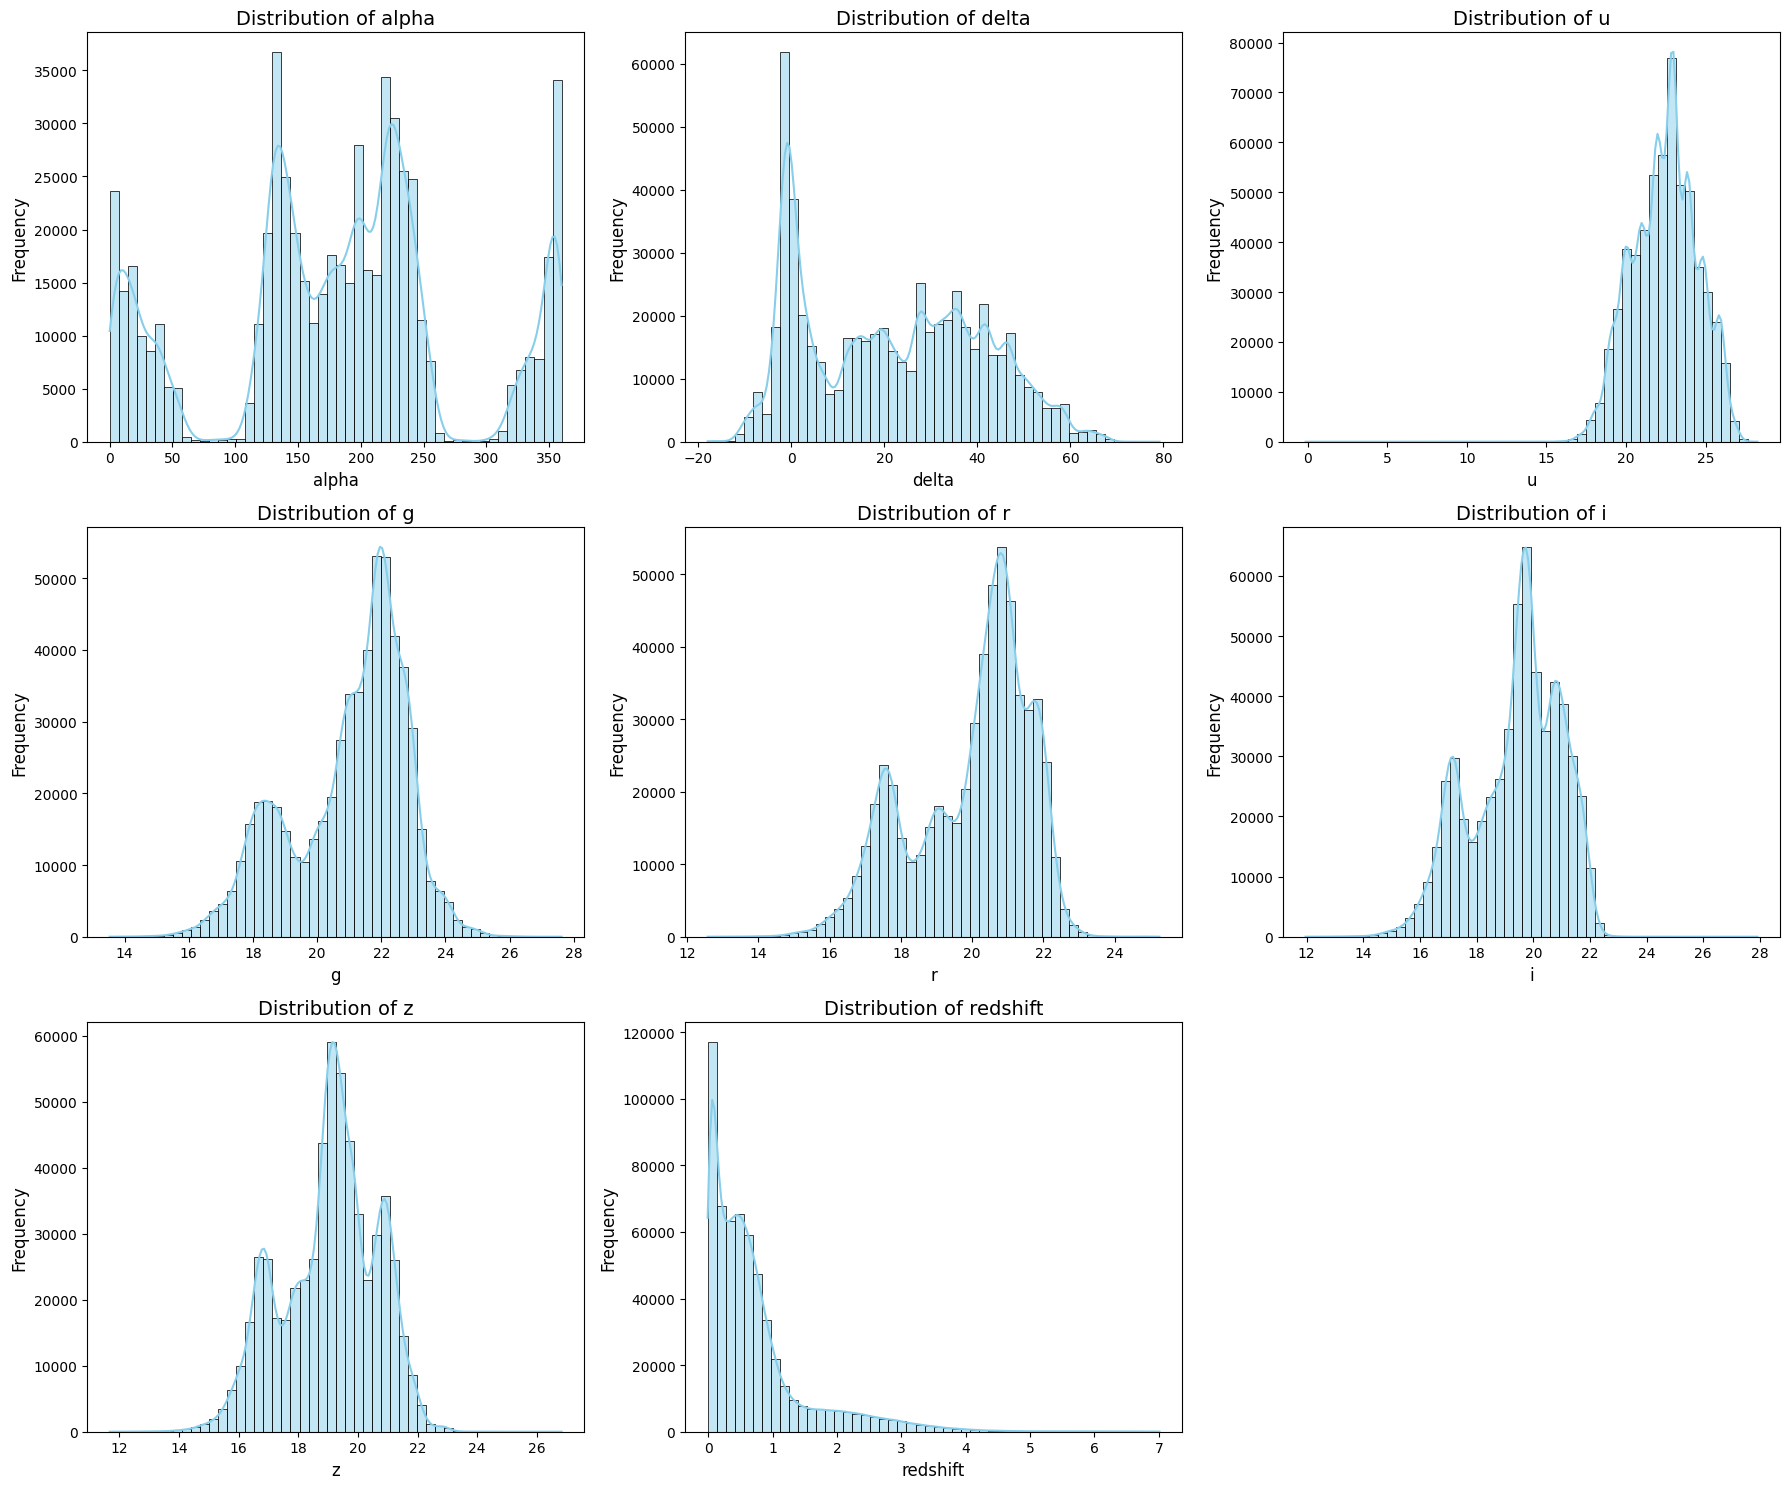

In [9]:
def plot_numerical_distributions(df, bins=50, sample_size=None):
    """
    Plots the distribution of specified numerical columns in a grid.
    
    Parameters:
    - df: pandas DataFrame
    - bins: int, number of histogram bins
    - sample_size: int, optional (randomly sample data for faster plotting on huge datasets)
    """
    temp_df = df.copy()
    numerical_columns = no_id_train_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    if sample_size and len(temp_df) > sample_size:
        data_to_plot = df.sample(n=sample_size, random_state=42)
    else:
        data_to_plot = temp_df
        
    n_cols = 3
    n_rows = math.ceil(len(numerical_columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() # Flatten to 1D array for easy iteration
    
    for i, col in enumerate(numerical_columns):
        # Plot histogram with density line
        sns.histplot(data_to_plot[col].dropna(), kde=True, ax=axes[i], 
                     bins=bins, color='skyblue', edgecolor='black')
        
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Frequency', fontsize=12)
        
    # Remove any empty subplots if the number of columns isn't a multiple of 3
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_numerical_distributions(preprocessed_categorical_train_df)

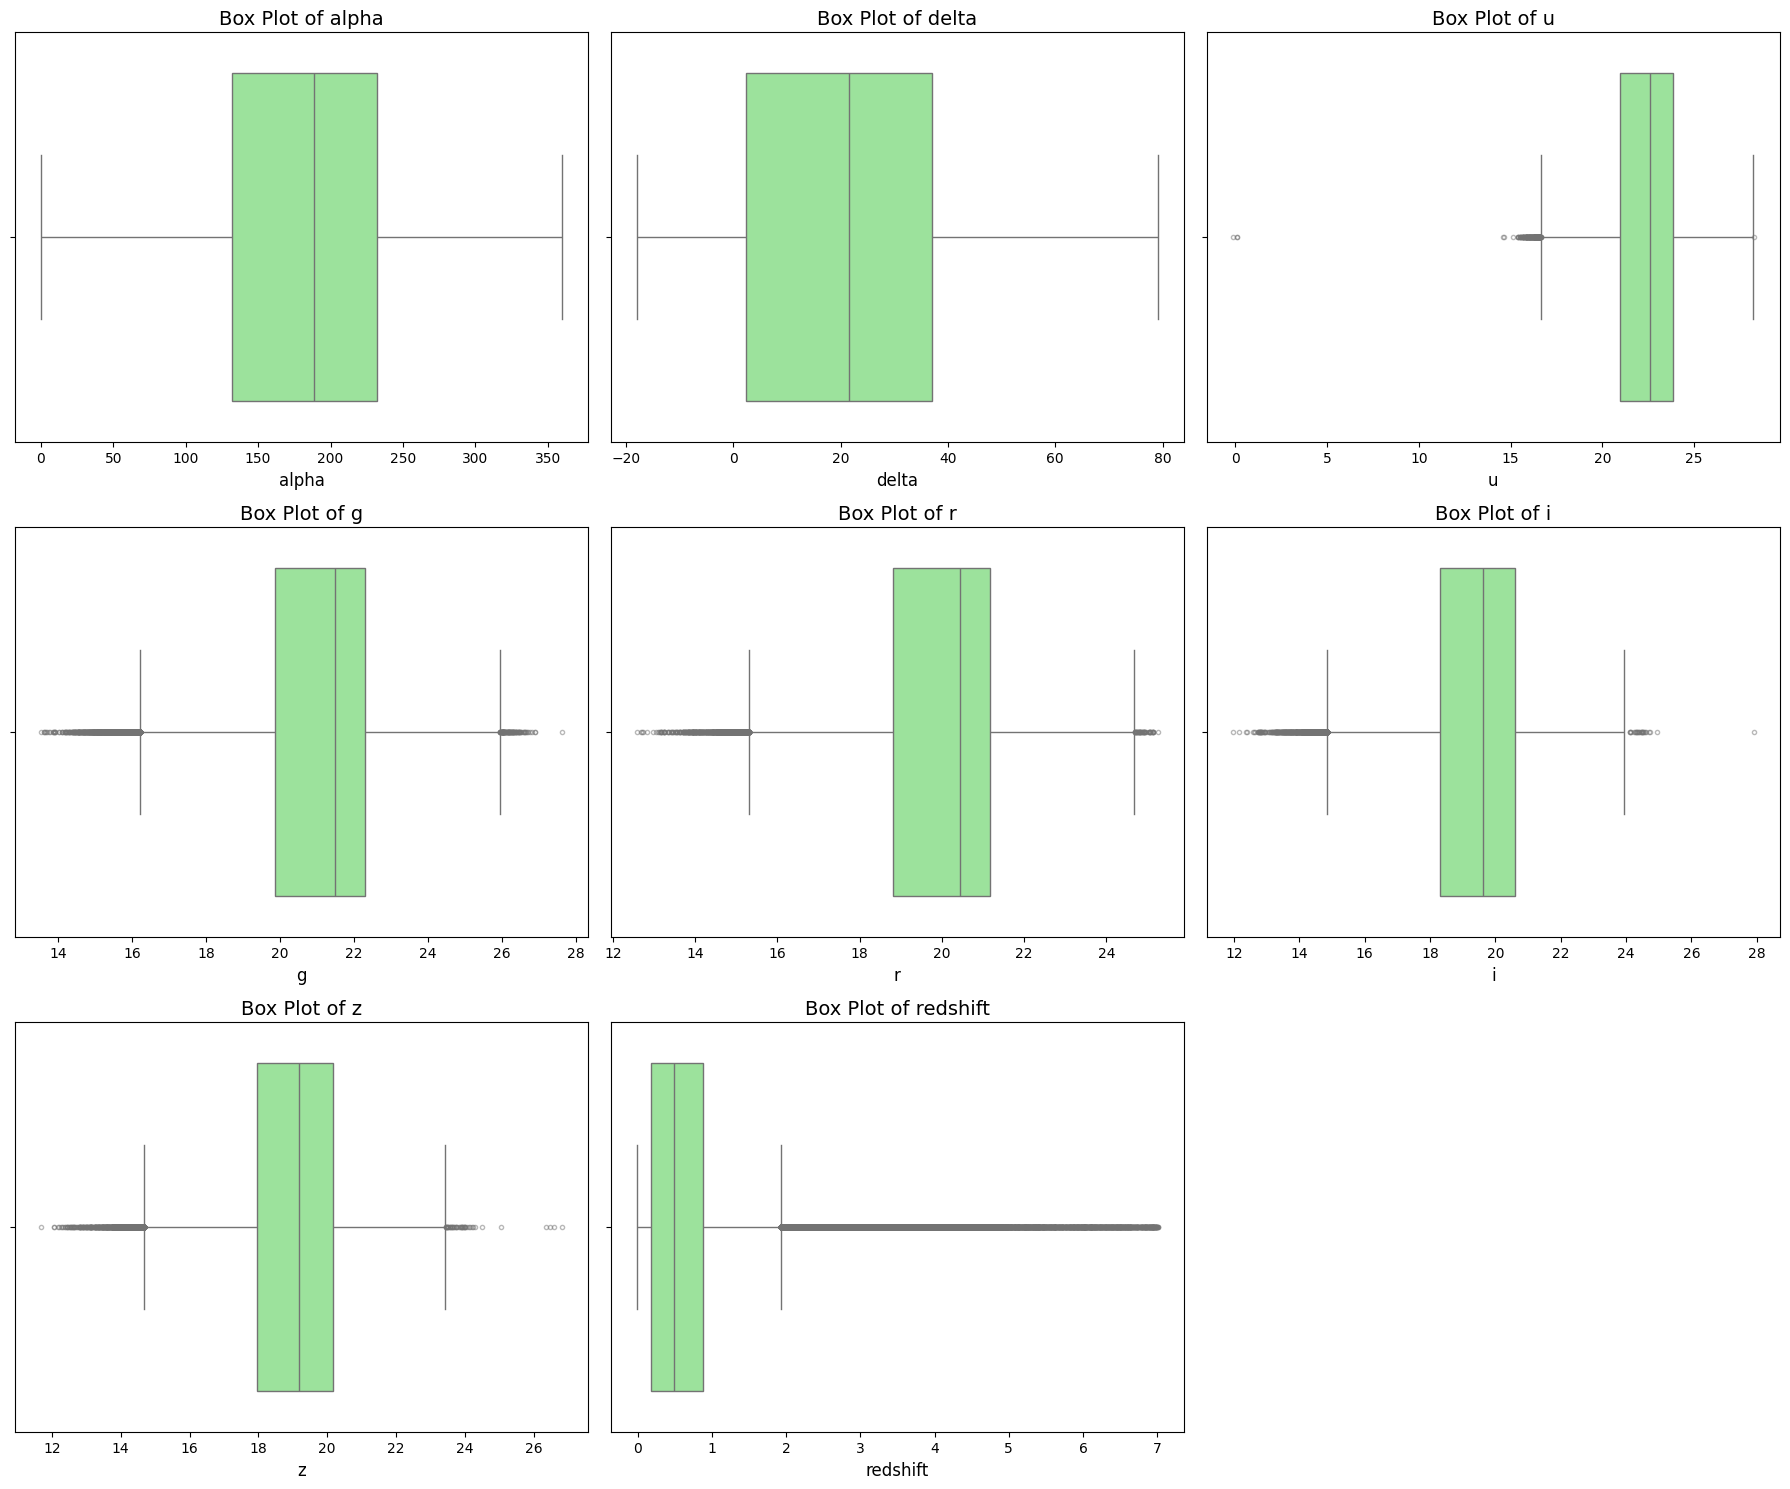

In [10]:
def plot_numerical_boxplots(df, sample_size=None):
    """
    Plots box plots of specified numerical columns in a grid.
    
    Parameters:
    - df: pandas DataFrame
    - sample_size: int, optional (randomly sample data for faster plotting)
    """
    temp_df = df.copy()
    numerical_columns = no_id_train_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    if sample_size and len(temp_df) > sample_size:
        data_to_plot = temp_df.sample(n=sample_size, random_state=42)
    else:
        data_to_plot = temp_df
        
    n_cols = 3
    n_rows = math.ceil(len(numerical_columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() # Flatten to 1D array for easy iteration
    
    for i, col in enumerate(numerical_columns):
        # Plot boxplot, styling the outlier dots slightly transparent
        sns.boxplot(x=data_to_plot[col].dropna(), ax=axes[i], color='lightgreen', 
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
        
        axes[i].set_title(f'Box Plot of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        
    # Remove any empty subplots if the number of columns isn't a multiple of 3
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_numerical_boxplots(preprocessed_categorical_train_df)

1. Coordinates: `alpha` and `delta`

**Scaler**: MinMaxScaler

**Why**: These are bounded spatial angles (Right Ascension and Declination). MinMaxScaler will compress them into a tight [0, 1] range while perfectly preserving the exact shape of their uniform/slightly skewed distributions. I don't want to standardize these because they don't have a true "center" (mean) in the traditional statistical sense.

2. The "Well-Behaved" Bands: `g`, `r`, and `i`

**Scaler**: StandardScaler

**Why**: As seen in the distributions, these three photometric bands are mostly bell-shaped (normal distributions) with relatively manageable outliers. StandardScaler will center them at a mean of 0 and a standard deviation of 1, which is exactly what Neural Networks and linear models expect.

3. The "Outlier-Heavy" Bands: `u` and `z`

**Scaler**: RobustScaler

**Why**: The box plots showed that u and z have a tight core but extreme outliers stretching far to the edges. If I use a StandardScaler, those massive outliers will skew the mean and standard deviation, crushing the rest of your normal data into a tiny range. RobustScaler ignores the outliers by scaling based on the Median and the Interquartile Range (IQR).

4. The Skewed Outlier: `redshift`

**Scaler**: QuantileTransformer (or RobustScaler)

**Why**: redshift is the trickiest feature. It has a massive spike near 0 and a long tail of extremely important outliers (which represent Quasars). A QuantileTransformer will smooth out this extreme skew by mapping the data to a normal or uniform distribution, preventing the massive 6.0+ outliers from overwhelming distance-based algorithms, while keeping them distinct from the 0.0 values.

In [11]:
def fit_transform_preprocess_numerical_features(df):
    '''
    Preprocess numerical features in the dataframe.
    Minmax scaler is used for apla and delta features.
    Standard scaler is used for g,r and i features.
    Robust scaler is used for u and z features. Due to outliers.
    Quantile transformer is used for redshift feature.

    
    Parameters:
    - df: pandas DataFrame

    Output: DataFrame with preprocessed numerical features 
    '''

    temp_df = df.copy()
    # Define the columns for each scaler
    minmax_cols = ['alpha', 'delta']
    standard_cols = ['g', 'r', 'i']
    robust_cols = ['u', 'z']
    quantile_cols = ['redshift']
    # Initialize scalers
    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()
    robust_scaler = RobustScaler()
    quantile_scaler = QuantileTransformer()
    # Apply MinMaxScaler to alpha and delta
    temp_df[minmax_cols] = minmax_scaler.fit_transform(temp_df[minmax_cols])
    # Apply StandardScaler to g, r, and i
    temp_df[standard_cols] = standard_scaler.fit_transform(temp_df[standard_cols])
    # Apply RobustScaler to u and z
    temp_df[robust_cols] = robust_scaler.fit_transform(temp_df[robust_cols])
    # Apply QuantileTransformer to redshift
    temp_df[quantile_cols] = quantile_scaler.fit_transform(temp_df[quantile_cols])
    return temp_df

preprocessed_numerical_train_df = fit_transform_preprocess_numerical_features(preprocessed_categorical_train_df)
preprocessed_numerical_train_df.head()


,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,0.410354,0.359600,1.003419,0.494750,0.239615,-0.077084,-0.259279,0.426100,0,0,0,1,0
1,0.355503,0.518029,-0.619538,-1.069503,-1.440665,-1.362510,-1.097421,0.232609,0,0,0,1,0
2,0.499408,0.548897,-0.530779,0.040021,0.733207,0.761819,0.625317,0.967153,1,1,0,0,1
3,0.627261,0.685057,0.254091,0.024207,-0.573122,-0.641276,-0.581861,0.528261,0,0,0,1,0
4,0.393970,0.384141,-0.299813,-0.855282,-1.048151,-0.936335,-0.718351,0.543511,0,0,0,1,0


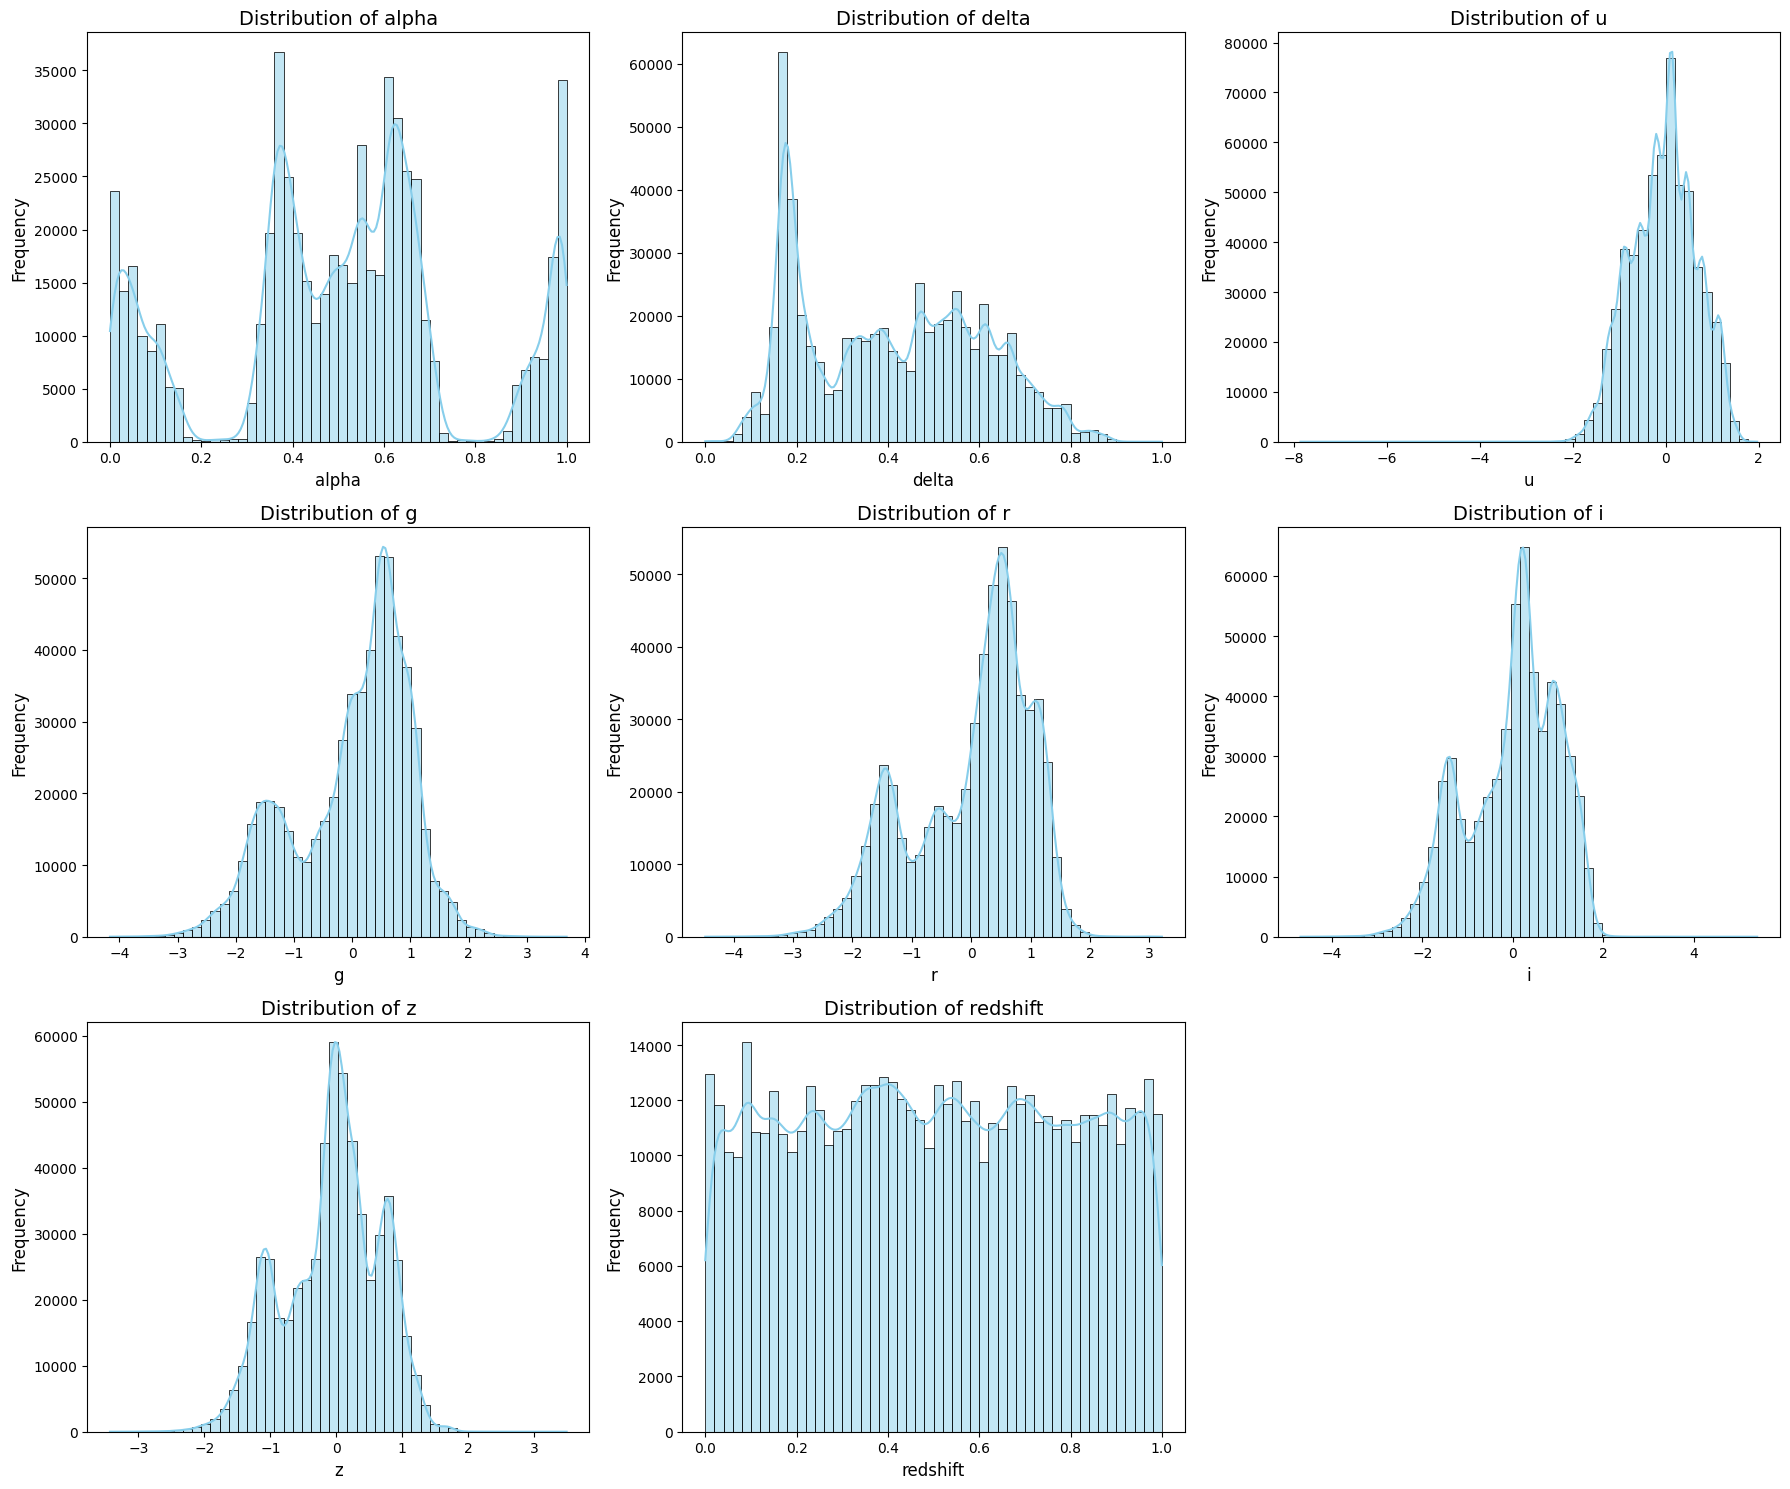

In [12]:
plot_numerical_distributions(preprocessed_numerical_train_df)

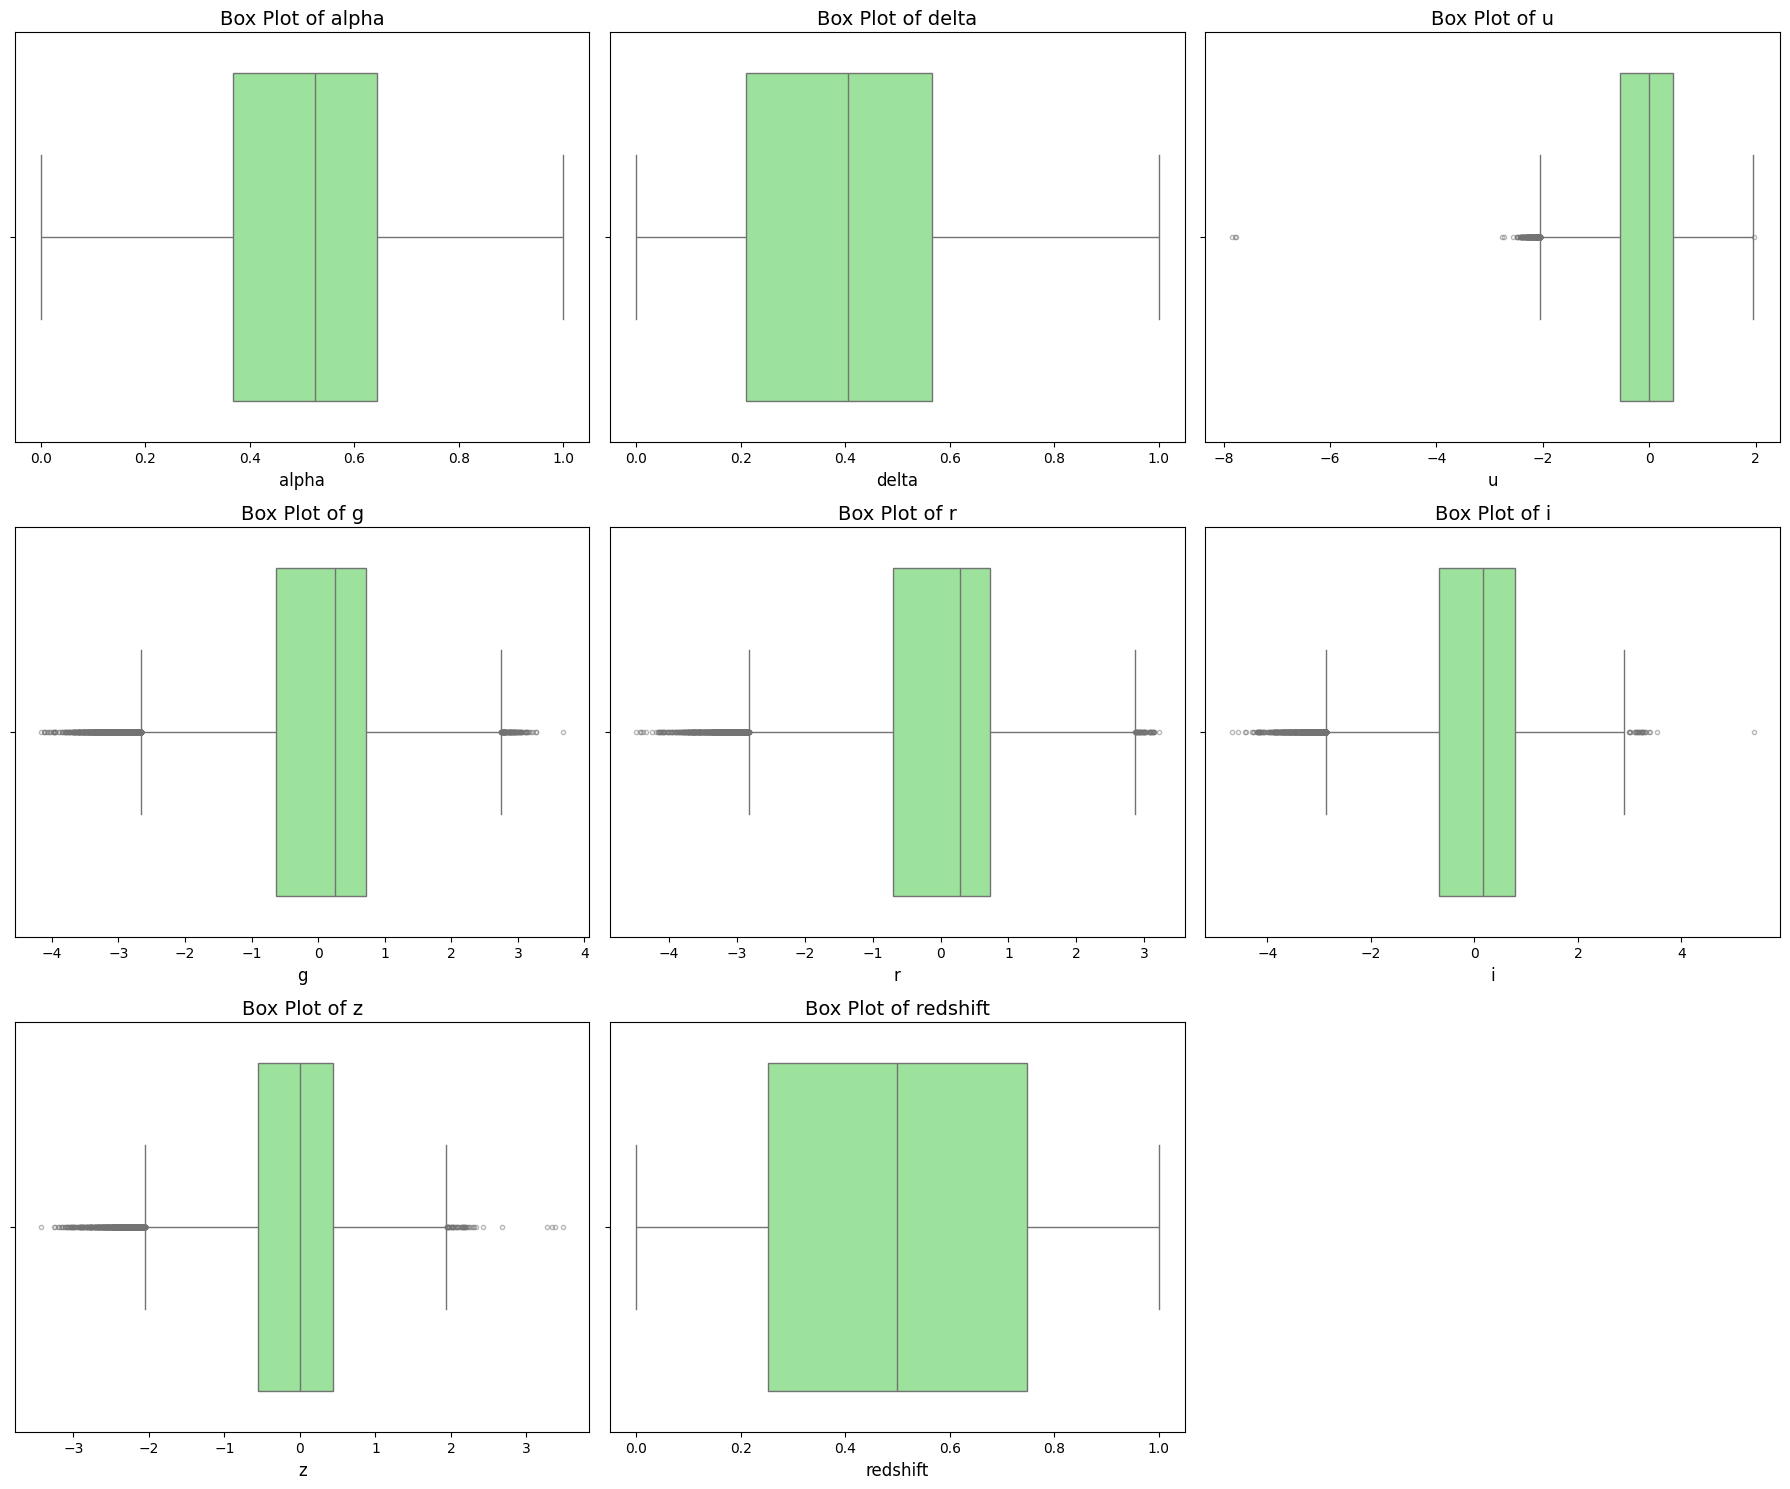

In [13]:
plot_numerical_boxplots(preprocessed_numerical_train_df)

In [14]:
preprocessed_numerical_train_df.head()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,0.410354,0.359600,1.003419,0.494750,0.239615,-0.077084,-0.259279,0.426100,0,0,0,1,0
1,0.355503,0.518029,-0.619538,-1.069503,-1.440665,-1.362510,-1.097421,0.232609,0,0,0,1,0
2,0.499408,0.548897,-0.530779,0.040021,0.733207,0.761819,0.625317,0.967153,1,1,0,0,1
3,0.627261,0.685057,0.254091,0.024207,-0.573122,-0.641276,-0.581861,0.528261,0,0,0,1,0
4,0.393970,0.384141,-0.299813,-0.855282,-1.048151,-0.936335,-0.718351,0.543511,0,0,0,1,0


# 4 Training the model

# 4.1 Base data training
In this iteration I use the preprocessed categorical features. This will allow me to establish a base accuracy score and determine which preprocessing steps will imporve accuracy

In [15]:
def prepare_training_data(df, target_col):
    '''Splits the dataframe into training and testing datasets.'''
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:


def train_and_evaluate_models(models_dict, X_train, X_test, y_train, y_test):
    '''
    Trains multiple models, evaluates them using classification reports, 
    and returns a DataFrame comparing their performance.
    '''
    results = []
    trained_models = {}
    
    for name, model_instance in models_dict.items():
        print(f"--- Training {name} ---")
        model_instance.fit(X_train, y_train)
        trained_models[name] = model_instance
        
        # Make predictions
        y_pred = model_instance.predict(X_test)
        
        # Evaluate
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        print(f"\nClassification Report for {name}:")
        print(classification_report(y_test, y_pred))
        print("=" * 60 + "\n")
        
        results.append({
            'Model': name,
            'Accuracy': acc,
            'Macro F1-Score': report['macro avg']['f1-score'],
            'Weighted F1-Score': report['weighted avg']['f1-score']
        })
        
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    return comparison_df, trained_models

# 1. Prepare Data
# Neural Networks and distance-based models require scaled data, so we switch to preprocessed_numerical_train_df
X_train, X_test, y_train, y_test = prepare_training_data(preprocessed_numerical_train_df, 'class')

# 2. Define Models
models_to_train = {
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'Neural Network (MLP)': MLPClassifier(random_state=42, max_iter=300),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

# 3. Train, Evaluate and Compare
comparison_df, trained_models = train_and_evaluate_models(models_to_train, X_train, X_test, y_train, y_test)

# 4. Assign the best model for the submission step
best_model_name = comparison_df.iloc[0]['Model']
model = trained_models[best_model_name]
print(f"Selected '{best_model_name}' as the best model for submission.\n")

# Display the comparison table
comparison_df

--- Training XGBoost ---

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     75694
           1       0.97      0.96      0.96     23243
           2       0.93      0.93      0.93     16533

    accuracy                           0.97    115470
   macro avg       0.96      0.96      0.96    115470
weighted avg       0.97      0.97      0.97    115470


--- Training Random Forest ---

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     75694
           1       0.96      0.96      0.96     23243
           2       0.91      0.90      0.90     16533

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470


--- Training Extra Trees ---

Classification Report for Extra Trees:
              precision    recall

,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,XGBoost,0.968251,0.956866,0.968250
1,HistGradientBoosting,0.963410,0.949893,0.963406
2,Random Forest,0.961159,0.946963,0.961120
3,Extra Trees,0.957894,0.941624,0.957779
4,Neural Network (MLP),0.956170,0.938374,0.955941
5,K-Nearest Neighbors,0.945934,0.924198,0.945707


# 5.Submission

In [17]:
# 1. Prepare test data
test_X = test_df.copy()
test_X = test_X.drop(columns=['id'])

# Map 'galaxy_population' the same as train_df (Red_Sequence -> 0, Blue_Cloud -> 1)
test_X['galaxy_population'] = test_X['galaxy_population'].map({'Red_Sequence': 0, 'Blue_Cloud': 1})

# One-hot encode 'spectral_type'
test_X = pd.get_dummies(test_X, columns=['spectral_type'], drop_first=True, dtype=int)

# Align column order with training data and fill any missing dummy columns with 0
test_X = test_X.reindex(columns=X_train.columns, fill_value=0)

# 2. Make predictions and map numerical predictions back to string labels
reverse_class_mapping = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
submission_df['class'] = pd.Series(model.predict(test_X)).map(reverse_class_mapping)

# 3. Save submission file
submission_df.to_csv('submission.csv', index=False)
print("Submission saved successfully!")
submission_df.head()

Submission saved successfully!


,id,class
0,577347,GALAXY
1,577348,QSO
2,577349,GALAXY
3,577350,STAR
4,577351,QSO
